In [1]:
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../src')
from utils import parsear_periodo

In [2]:
df_paises = pd.read_csv('../data/processed/exportaciones_long.csv', parse_dates=['periodo'])
df_totales = pd.read_csv('../data/processed/exportaciones_totales_long.csv', parse_dates=['periodo'])
df_imp_paises = pd.read_csv('../data/processed/importaciones_long.csv', parse_dates=['periodo'])
df_imp_totales = pd.read_csv('../data/processed/importaciones_totales_long.csv', parse_dates=['periodo'])

In [3]:
df_totales.head()

,periodo,region,exportaciones_musd
0,2003-01-01,América. América del Norte. Total,527.270501
1,2003-02-01,América. América del Norte. Total,398.176027
2,2003-03-01,América. América del Norte. Total,508.960943
3,2003-04-01,América. América del Norte. Total,501.489078
4,2003-05-01,América. América del Norte. Total,401.180996


In [4]:
totales_continentes = df_totales[
    df_totales['region'].isin([
        'América. América del Norte. Total',
        'América. América del Sur. Total',
        'Europa. Total',
        'Asia. Total'
    ])
]

<function matplotlib.pyplot.show(close=None, block=None)>

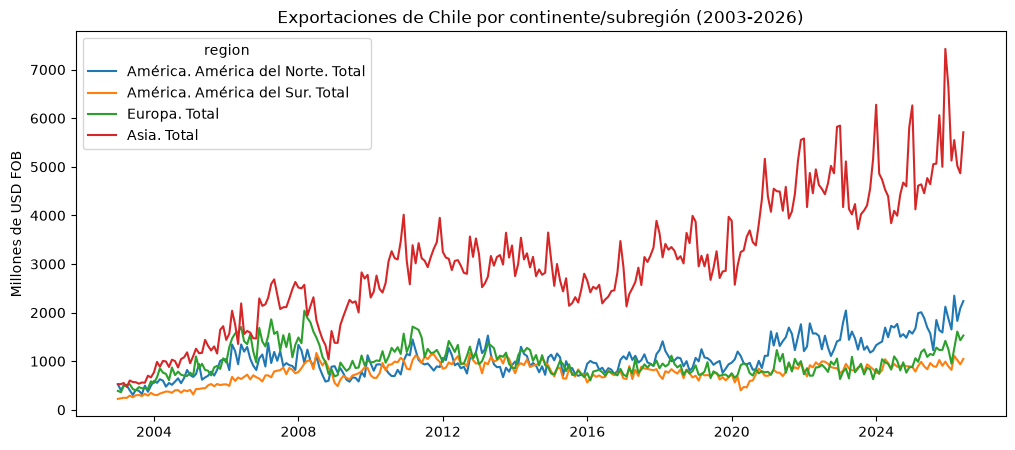

In [5]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=totales_continentes,
    x='periodo',
    y='exportaciones_musd',
    hue='region'
)
plt.title('Exportaciones de Chile por continente/subregión (2003-2026)')
plt.ylabel('Millones de USD FOB')
plt.xlabel('')
plt.show

In [6]:
# Comparamos el cambio de régimen pre/post 2020
totales_continentes['periodo'] = totales_continentes['periodo'].dt.year
(totales_continentes
    .groupby(['region', totales_continentes['periodo'] >= 2020])
    ['exportaciones_musd']
    .mean()
    .unstack()
)

periodo,False,True
region,,
América. América del Norte. Total,904.725964,1476.151603
América. América del Sur. Total,741.335473,841.335510
Asia. Total,2394.948086,4612.416752
Europa. Total,1003.641957,942.602075


In [7]:
df_cobre = pd.read_csv('../data/raw/precio_cobre_bml.csv')
df_cobre['periodo'] = pd.to_datetime(df_cobre['periodo'].apply(parsear_periodo))
df_cobre.head()

,periodo,precio_cobre_usd_lb
0,2003-01-01,0.747
1,2003-02-01,0.764
2,2003-03-01,0.753
3,2003-04-01,0.720
4,2003-05-01,0.748


In [8]:
asia_total = df_totales[
    df_totales['region'] == 'Asia. Total'
][
    ['periodo', 'exportaciones_musd']
]

df_cruce = pd.merge(
    asia_total,
    df_cobre,
    on='periodo',
    how='inner'
)

df_cruce.head()

,periodo,exportaciones_musd,precio_cobre_usd_lb
0,2003-01-01,525.964778,0.747
1,2003-02-01,530.279186,0.764
2,2003-03-01,551.404989,0.753
3,2003-04-01,471.338878,0.720
4,2003-05-01,603.060827,0.748


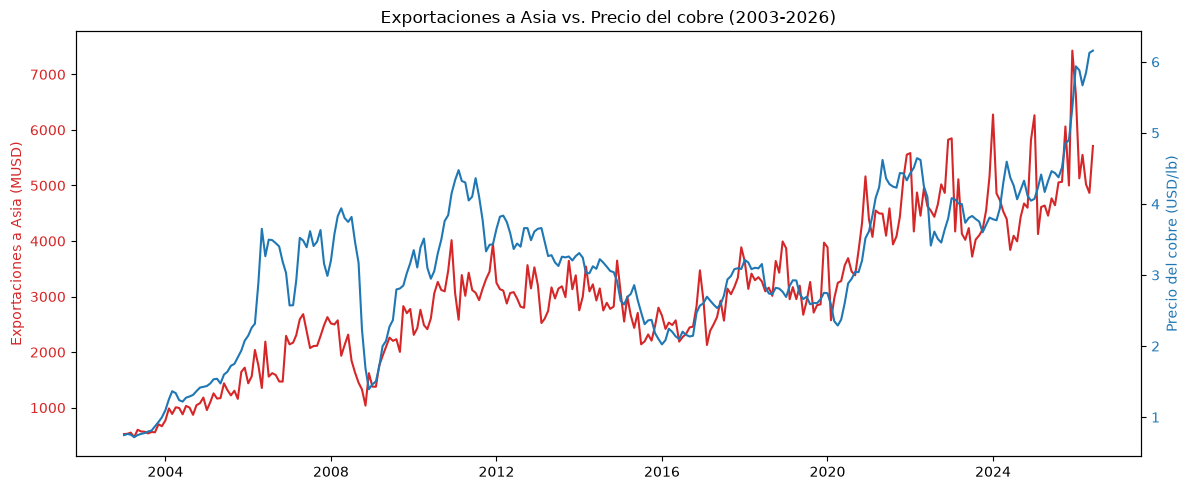

                     exportaciones_musd  precio_cobre_usd_lb
exportaciones_musd             1.000000             0.815869
precio_cobre_usd_lb            0.815869             1.000000


In [9]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    df_cruce['periodo'],
    df_cruce['exportaciones_musd'],
    color='tab:red',
    label='Exportaciones a Asia'
)
ax1.set_ylabel('Exportaciones a Asia (MUSD)',
    color='tab:red'
)
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.plot(
    df_cruce['periodo'],
    df_cruce['precio_cobre_usd_lb'],
    color='tab:blue',
    label='Precio del cobre'
)
ax2.set_ylabel('Precio del cobre (USD/lb)',
    color='tab:blue'
)
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Exportaciones a Asia vs. Precio del cobre (2003-2026)')
fig.tight_layout()
plt.show()

print(df_cruce[['exportaciones_musd', 'precio_cobre_usd_lb']].corr())

In [10]:
df_cruce['periodo_grupo'] = df_cruce['periodo'].dt.year < 2012
df_cruce.groupby('periodo_grupo')[
    ['exportaciones_musd', 'precio_cobre_usd_lb']
].corr().iloc[0::2, -1]

periodo_grupo                    
False          exportaciones_musd    0.796588
True           exportaciones_musd    0.851664
Name: precio_cobre_usd_lb, dtype: float64

In [11]:
df_volumen = pd.read_csv('../data/raw/volumen_exportacion_cobre.csv')
df_volumen['periodo'] = pd.to_datetime(df_volumen['periodo'].apply(parsear_periodo))

df_cruce_completo = pd.merge(df_cruce, df_volumen, on='periodo', how='inner')
df_cruce_completo.head()
print(f"Filas: {len(df_cruce_completo)}")

Filas: 41


In [12]:
df_cruce_completo[['exportaciones_musd', 'precio_cobre_usd_lb', 'volumen_cobre_ktm']].corr()

,exportaciones_musd,precio_cobre_usd_lb,volumen_cobre_ktm
exportaciones_musd,1.000000,0.438247,0.019362
precio_cobre_usd_lb,0.438247,1.000000,-0.040007
volumen_cobre_ktm,0.019362,-0.040007,1.000000


In [13]:
primeros_6 = df_cruce_completo.head(6)
ultimos_6 = df_cruce_completo.tail(6)

for col in ['exportaciones_musd', 'precio_cobre_usd_lb', 'volumen_cobre_ktm']:
    prom_inicio = primeros_6[col].mean()
    prom_fin = ultimos_6[col].mean()
    variacion = (prom_fin - prom_inicio) / prom_inicio * 100
    print(f"{col}: {variacion:.1f}%  (de {prom_inicio:.1f} a {prom_fin:.1f})")

exportaciones_musd: 25.8%  (de 4586.5 a 5771.8)
precio_cobre_usd_lb: 47.0%  (de 3.9 a 5.8)
volumen_cobre_ktm: 4.9%  (de 442.3 a 464.1)


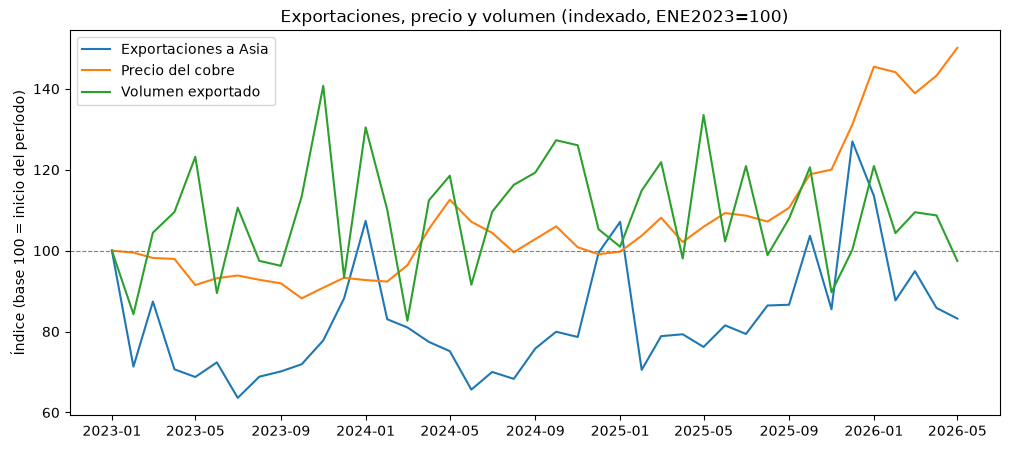

In [14]:
df_normalizado = df_cruce_completo.copy()

for col in ['exportaciones_musd', 'precio_cobre_usd_lb', 'volumen_cobre_ktm']:
    valor_base = df_normalizado[col].iloc[0]
    df_normalizado[f'{col}_indice'] = df_normalizado[col] / valor_base * 100

plt.figure(figsize=(12, 5))
plt.plot(df_normalizado['periodo'], df_normalizado['exportaciones_musd_indice'], label='Exportaciones a Asia')
plt.plot(df_normalizado['periodo'], df_normalizado['precio_cobre_usd_lb_indice'], label='Precio del cobre')
plt.plot(df_normalizado['periodo'], df_normalizado['volumen_cobre_ktm_indice'], label='Volumen exportado')

plt.axhline(100, color='gray', linestyle='--', linewidth=0.8)
plt.title('Exportaciones, precio y volumen (indexado, ENE2023=100)')
plt.ylabel('Índice (base 100 = inicio del período)')
plt.legend()
plt.show()

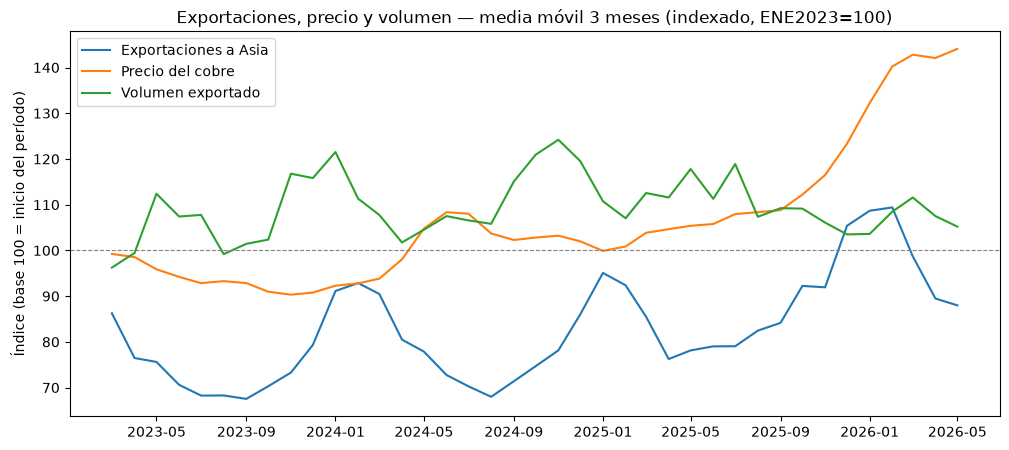

In [15]:
plt.figure(figsize=(12, 5))
for col, label in [
    ('exportaciones_musd_indice', 'Exportaciones a Asia'),
    ('precio_cobre_usd_lb_indice', 'Precio del cobre'),
    ('volumen_cobre_ktm_indice', 'Volumen exportado')
]:
    plt.plot(df_normalizado['periodo'], df_normalizado[col].rolling(3).mean(), label=label)

plt.axhline(100, color='gray', linestyle='--', linewidth=0.8)
plt.title('Exportaciones, precio y volumen — media móvil 3 meses (indexado, ENE2023=100)')
plt.ylabel('Índice (base 100 = inicio del período)')
plt.legend()
plt.show()

In [16]:
ultimo_periodo = df_paises['periodo'].max()
ranking_actual = (
    df_paises[df_paises['periodo'] == ultimo_periodo]
    .sort_values('exportaciones_musd', ascending=False)
)
ranking_actual[['pais', 'exportaciones_musd']]

,pais,exportaciones_musd
1973,China,3697.351000
281,Estados Unidos,1861.519842
1691,Unión Europea,1115.825347
2255,Japón,861.548184
1127,Brasil,444.372654
2537,Corea del Sur,419.400935
845,Canadá,240.756188
563,México,135.424968
1409,Argentina,91.264206


In [17]:
paises_asia = ['Asia. China', 'Asia. Japón', 'Asia. Corea del Sur']
df_asia_paises = df_paises[df_paises['destino'].isin(paises_asia)].copy()

df_asia_paises['año'] = df_asia_paises['periodo'].dt.year
(df_asia_paises
    .groupby(['pais', df_asia_paises['año'] >= 2020])
    ['exportaciones_musd']
    .mean()
    .unstack()
)

año,False,True
pais,,
China,1168.160903,3048.630147
Corea del Sur,309.329082,437.570711
Japón,522.946578,646.793241


In [18]:
crecimiento_asia = df_asia_paises.groupby(['pais', df_asia_paises['año'] >= 2020])['exportaciones_musd'].mean().unstack()
crecimiento_asia['variacion_pct'] = (crecimiento_asia[True] - crecimiento_asia[False]) / crecimiento_asia[False] * 100
crecimiento_asia

año,False,True,variacion_pct
pais,,,
China,1168.160903,3048.630147,160.976903
Corea del Sur,309.329082,437.570711,41.457993
Japón,522.946578,646.793241,23.682469


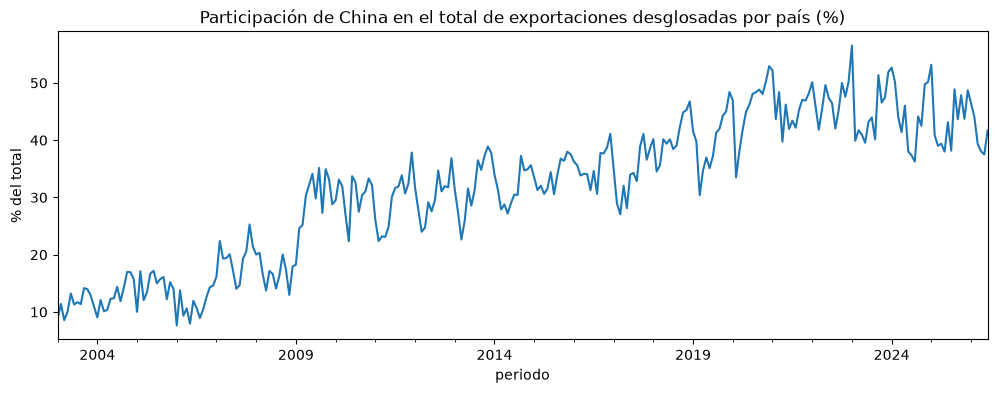

Participación promedio 2003-2019: 26.6%
Participación promedio 2020-2026: 44.9%


In [19]:
total_por_periodo = df_paises.groupby('periodo')['exportaciones_musd'].sum()
china_por_periodo = df_paises[df_paises['pais'] == 'China'].set_index('periodo')['exportaciones_musd']

participacion_china = (china_por_periodo / total_por_periodo * 100)

plt.figure(figsize=(12, 4))
participacion_china.plot()
plt.title('Participación de China en el total de exportaciones desglosadas por país (%)')
plt.ylabel('% del total')
plt.show()

print(f"Participación promedio 2003-2019: {participacion_china[participacion_china.index.year < 2020].mean():.1f}%")
print(f"Participación promedio 2020-2026: {participacion_china[participacion_china.index.year >= 2020].mean():.1f}%")